# 14 · 손실·정규화·가중치 감쇠가 바꾸는 계산

**이번 질문:** 같은 모델·같은 데이터에서 잔차에 매기는 비용, 관측의 가중치, 가중치의 벌점, 감쇠의 자리, 무작위 mask를 바꾸면 기울기와 학습 결과의 어느 자리가 달라질까요?

이상치가 있는 회귀에 MSE·MAE·Huber를 적용하고, 샘플 가중치와 L2의 미분을 직접 계산합니다. AdamW의 갱신과 dropout의 평균 효과를 작은 숫자로 확인합니다.
같은 계산을 MNIST 7 판별 가중치와 7 이미지에도 적용해 L2와 dropout이 실제로 무엇을 바꾸는지 봅니다.

- 준비물: [01](../00_기초/01_gradients_and_learning.ipynb)의 미분, [02](../00_기초/02_probability_and_losses.ipynb)의 관측 모형과 손실, [04](../00_기초/04_optimizers.ipynb)의 Adam.
- 도착점: 손실·가중치·L2·AdamW·dropout 각각의 forward와 미분을 직접 쓰고, 해석해(ridge)·손계산·중심차분·모든 mask의 합으로 검산합니다.
- 다음 연결: [15 실험과 평가](15_experiments_evaluation.ipynb)에서 데이터를 나누고 지표·반복 실험으로 이런 선택을 비교합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 손실은 잔차 $r=\hat y-y$에 비용을 매기는 함수이고, 학습에 들어가는 것은 그 미분 $\rho'(r)$입니다. half-MSE는 $r$, MAE는 $\mathrm{sign}(r)$, Huber는 $\mathrm{clip}(r,-\delta,\delta)$라서 큰 잔차의 영향이 다릅니다.
2. 평균의 분모를 정확히 적습니다. 관측 가중치는 $a_n/(K\sum_ma_m)$로 각 원소에 붙고, L2는 평균 데이터 손실에 $\frac\lambda2\|W\|^2$를 더해 $dW$에 $\lambda W$가 붙습니다. 이 계수 규약이 ridge 해 $(A^\top A+NK\lambda P)\theta=A^\top Y$를 정합니다.
3. AdamW는 감쇠 $\lambda W$를 Adam 상태에 넣지 않고 $(1-\eta\lambda)W$로 따로 곱합니다. dropout은 mask를 고정하면 $dH=G\odot M/q$이고, 선형 모델의 제곱 손실에서 mask의 평균 목적은 L2 모양의 항을 더한 것입니다.

| 선택 | 바뀌는 자리 | 이 단원에서 확인할 것 |
|---|---|---|
| MSE·MAE·Huber | 잔차에서 손실과 기울기 | 큰 잔차의 영향 |
| 샘플 가중치 | 관측 기여의 평균 | 정규화 분모와 배치 미분 |
| L2 | 목적에 파라미터 제곱합 추가 | $\lambda W$ 기울기 |
| AdamW | 적응적 갱신과 별도의 감쇠 | 상태에 들어가는 기울기 |
| dropout | 학습 순전파에 무작위 mask | 고정 mask의 미분과 평균 목적 |

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/regularization_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/regularization_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist, load_examples
from src.utils.regularization_plots import (
    plot_curves, plot_loss_shapes, plot_weighted_mean, plot_l2_templates, plot_decay_comparison, plot_dropout_masks,
    plot_dropout_objective, plot_outlier_fits, plot_ridge_norms,
)

# 3) 그림 설정 (마지막 줄이라 고른 글꼴 이름이 셀 아래에 표시됩니다)
setup_plots()

'Arial Unicode MS'

### 📎 이 노트북의 예시: 이상치가 있는 직선, 작은 손계산 배열, MNIST 7

- **이상치가 있는 직선.** $y=2x+0.4$에 작은 잡음을 더한 80점 중 10점에 +7을 더합니다. 세 손실이 이 이상치를 얼마나 따라가는지 봅니다.
- **작은 손계산 배열.** 관측 3개·출력 2개의 예측·정답·가중치, 좌표 2개의 Adam 한 스텝, 특성 2개의 dropout mask 네 종류.
- **MNIST 7.** 01번의 "7이면 1" 회귀 가중치를 L2 세기별 닫힌 해로 구해 이미지로 보고, 고정 예시 7에 dropout mask를 씌웁니다. 학습 5,000장을 씁니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `(mnist_y_all[:5000] == 7).astype(float)[:, None]`: 비교 결과 True/False를 1.0/0.0으로 바꾼 뒤 `(5000, 1)` 열벡터로 세웁니다.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)          # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_7 = mnist_examples[7]                                           # (28, 28): 고정 예시 7
mnist_X_all, mnist_y_all, _, _ = load_mnist()                         # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X = mnist_X_all[:5000]                                          # (5000, 784): 학습 집합 앞 5,000장
mnist_T = (mnist_y_all[:5000] == 7).astype(float)[:, None]            # (5000, 1): 7이면 1
print("MNIST", mnist_X.shape, "· 7의 비율", mnist_T.mean().round(3))

MNIST (5000, 784) · 7의 비율 0.11


## 🔑 1. 같은 잔차에 다른 비용 주기

**이 절에서 가져갈 것:** 손실은 잔차 $r$에 비용을 매기는 함수 $\rho(r)$이고, 역전파에 들어가는 것은 $\rho'(r)$입니다. half-MSE는 잔차에 비례해 커지는 기울기를, MAE는 크기 1의 기울기를, Huber는 $\delta$에서 잘라 낸 기울기를 전달합니다.

직선을 맞추는데 관측 하나가 엉뚱하게 7만큼 위에 있다고 합시다. 제곱 손실은 이 한 점의 잔차 7을 49로 세어 직선을 그쪽으로 끌어당깁니다. 절댓값 손실은 7로만 세고, Huber는 $\delta$까지만 제곱으로 세고 그 밖은 직선으로 셉니다.

> **용어**
>
> - **잔차(residual)** $r=\hat y-y$: 예측에서 정답을 뺀 값. 손실은 잔차의 함수 $\rho(r)$, 기울기는 $\rho'(r)$.
> - **이상치(outlier)**: 나머지 관측과 동떨어진 큰 잔차를 만드는 관측. 손실의 모양에 따라 영향이 다릅니다.
> - **부분기울기(subgradient)**: 꺾이는 점에서 쓸 수 있는 기울기의 집합. $|r|$의 0에서는 $[-1,1]$이고 코드는 0을 고릅니다.

잔차를 $r=\hat y-y$로 정합니다. 이 단원의 MSE 표기는 미분이 $r$인 **half-MSE**를 뜻합니다.

| 손실 $\rho(r)$ | 식 | 잔차에 대한 미분 |
|---|---|---|
| half-MSE | $r^2/2$ | $r$ |
| MAE | $\lvert r\rvert$ | $\operatorname{sign}(r)$ |
| Huber | $\lvert r\rvert\le\delta$에서 $r^2/2$, 그 밖에서 $\delta(\lvert r\rvert-\delta/2)$ | $\operatorname{clip}(r,-\delta,\delta)$ |

MAE의 $r=0$에서는 부분기울기 0을 선택합니다.
Huber는 경계의 값과 1차 미분이 이어지도록 선형 부분을 정했습니다.
$\delta=.5$, $r=2$라면 세 손실은 각각 $2,2,.875$이고 미분은 $2,1,.5$입니다.

📎 조건부 Gaussian의 고정 분산은 MSE, 조건부 Laplace의 고정 scale은 MAE에 대응합니다.
제곱 오차의 기대값은 조건부 평균에서, 절댓값 오차는 조건부 중앙값에서 최소화됩니다.
어떤 잔차를 얼마나 반영할지 관측 가정과 함께 고릅니다.

아래는 잔차 $-3$부터 $3$까지 세 손실과 미분을 NumPy로 직접 계산한 것입니다.

> **코드**
>
> - `np.where(np.abs(r) <= delta, r²/2, …)`: 자리마다 조건이 참이면 앞 값, 거짓이면 뒤 값. Huber의 두 구간을 한 줄로 씁니다.
> - `np.sign(r)`: 부호 −1/0/+1. `np.clip(r, -delta, delta)`: 범위 밖 값을 경계값으로 자릅니다.
> - `np.argmin(np.abs(shape_r - 2.))`: 격자에서 2에 가장 가까운 자리의 번호.
> - `{name: … for name in […]}`: 손실 이름마다 곡선을 계산해 사전으로 모읍니다(사전 컴프리헨션).

In [3]:
shape_r = np.linspace(-3, 3, 301)                                     # (301,): 잔차 r
shape_delta = 0.5                                                     # Huber의 δ
shape_losses = {"mse": 0.5 * shape_r ** 2, "mae": np.abs(shape_r),    # 손실 ρ(r) 셋
                "huber": np.where(np.abs(shape_r) <= shape_delta, 0.5 * shape_r ** 2, shape_delta * (np.abs(shape_r) - 0.5 * shape_delta))}
shape_grads = {"mse": shape_r, "mae": np.sign(shape_r), "huber": np.clip(shape_r, -shape_delta, shape_delta)}   # 미분 ρ'(r) 셋
at_two = np.argmin(np.abs(shape_r - 2.))                              # r = 2인 자리
print("r = 2 에서 손실:", [round(float(shape_losses[k][at_two]), 3) for k in ("mse", "mae", "huber")],
      "· 미분:", [round(float(shape_grads[k][at_two]), 3) for k in ("mse", "mae", "huber")])

r = 2 에서 손실: [2.0, 2.0, 0.875] · 미분: [2.0, 1.0, 0.5]


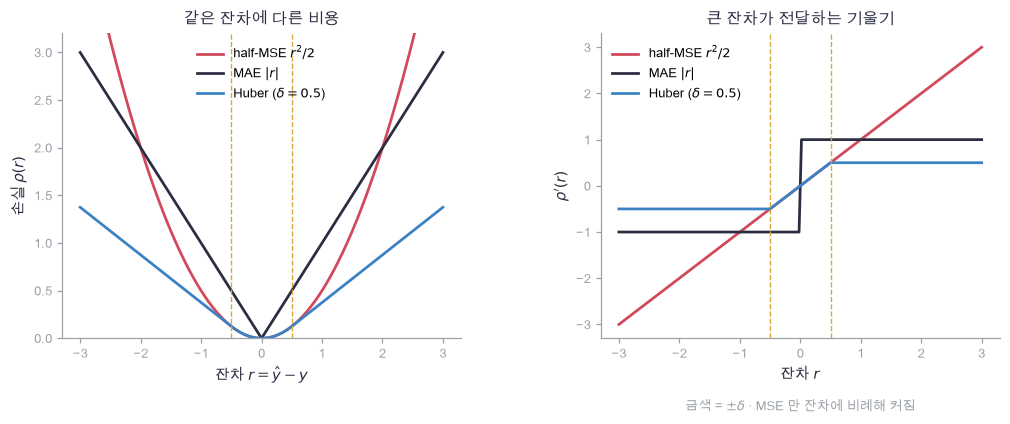

In [4]:
plot_loss_shapes(shape_r, shape_losses, shape_grads, shape_delta)

🔍 **확인** · 왼쪽에서 $|r|\le\delta$ 안에서는 Huber와 half-MSE가 같고, 밖에서 Huber는 직선으로 꺾입니다. 오른쪽에서 MSE만 잔차에 비례해 기울기가 커지고 MAE는 $\pm1$, Huber는 $\pm\delta$에서 멈춥니다. 잔차 7인 이상치는 MSE에서 7배, Huber에서 0.5배의 기울기를 냅니다.
서로 다른 손실의 숫자 크기는 각자의 정의를 따릅니다. 모델 비교에는 같은 평가 지표를 적용합니다. 아래 구현은 세 손실의 값과 미분을 한 함수로 씁니다.

In [5]:
def element_loss(residual, kind, delta=.5):
    """원소별 손실 ρ(r)와 미분 ρ'(r). kind: 'mse'(r²/2, r) | 'mae'(|r|, sign r) | 'huber'(δ 안 r²/2, 밖 δ(|r| − δ/2); clip(r, −δ, δ)).
    residual: 어떤 모양 → (loss, grad: 같은 모양)."""
    if kind == 'mse':
        return .5 * residual**2, residual
    if kind == 'mae':
        return np.abs(residual), np.sign(residual)          # r = 0에서는 부분기울기 0
    if kind == 'huber' and delta > 0:
        magnitude = np.abs(residual)
        loss = np.where(magnitude <= delta, .5 * residual**2, delta * (magnitude - .5*delta))   # 안은 제곱, 밖은 직선 (경계에서 이어짐)
        return loss, np.clip(residual, -delta, delta)
    raise ValueError('mse·mae·huber와 양의 delta를 사용합니다.')

In [6]:
# 쓰는 것: shape_losses, shape_grads (1절 그림 셀)
for kind, expected_loss, expected_grad in [('mse', 2., 2.), ('mae', 2., 1.), ('huber', .875, .5)]:   # r = 2, δ = 0.5의 손계산
    loss, grad = element_loss(np.array([2.]), kind, .5)
    np.testing.assert_allclose(loss, expected_loss)         # 검산: 손실 손계산
    np.testing.assert_allclose(grad, expected_grad)         # 검산: 미분 손계산
residual_axis = np.linspace(-3, 3, 301)
loss_curves = {name: element_loss(residual_axis, name)[0] for name in ['mse', 'mae', 'huber']}      # 이름 → 손실 곡선
gradient_curves = {name: element_loss(residual_axis, name)[1] for name in ['mse', 'mae', 'huber']}  # 이름 → 미분 곡선
print('손계산 통과: r=2, delta=0.5')
for kind in ("mse", "mae", "huber"):
    np.testing.assert_allclose(loss_curves[kind], shape_losses[kind])        # 검산: 위 그림의 손실 곡선과 같음
    np.testing.assert_allclose(gradient_curves[kind], shape_grads[kind])     # 검산: 미분 곡선도 같음

손계산 통과: r=2, delta=0.5


🔍 **확인** · $r=2$, $\delta=0.5$의 손계산 $(2, 2, 0.875)$와 $(2, 1, 0.5)$가 맞고, 위 그림의 곡선도 같은 함수가 냅니다.

### ✏️ 연습 1 · 이상치 하나가 전달하는 기울기

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

잔차 배열 `residual`과 `delta`에서 half-MSE·MAE·Huber가 역전파에 전달하는 미분 $\rho'(r)$ 셋을 만드는 세 줄을 채우세요. 손실값이 아니라 미분만 냅니다. 검사는 이상치 잔차 7에서 세 미분이 $7, 1, 0.5$로 갈리는지 봅니다.

In [7]:
def exercise_three_gradients(residual, delta):
    """연습 1: 세 손실이 역전파에 전달하는 미분 ρ'(r). residual: (N,), delta: 양수 → (grad_mse, grad_mae, grad_huber: 각각 (N,))."""
    assert delta > 0, "delta는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: half-MSE의 미분 grad_mse, MAE의 미분 grad_mae, Huber의 미분 grad_huber (셋 다 residual과 같은 모양)
    ### 힌트: 1절 표의 "잔차에 대한 미분" 열 세 칸입니다. 그림 셀의 shape_grads 사전이 같은 셋을 만들었습니다 (np.sign, np.clip).
    raise NotImplementedError
    return grad_mse, grad_mae, grad_huber

In [8]:
def check_three_gradients(candidate):
    """이상치 잔차 7을 포함한 손계산 하나와 본문 element_loss로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: element_loss (1절)
    example_r = np.array([7., -.3, 0.])                        # (3,): 이상치, 작은 음수, 0
    grad_mse, grad_mae, grad_huber = candidate(example_r, .5)
    assert np.shape(grad_huber) == (3,), f"미분은 잔차와 같은 모양 (3,)이어야 하는데 {np.shape(grad_huber)}입니다"
    np.testing.assert_allclose(grad_mse, [7., -.3, 0.])        # 검산: half-MSE는 잔차 그대로. 이상치가 7배 기울기
    np.testing.assert_allclose(grad_mae, [1., -1., 0.])        # 검산: MAE는 부호. r = 0에서는 부분기울기 0
    np.testing.assert_allclose(grad_huber, [.5, -.3, 0.])      # 검산: Huber는 δ = 0.5에서 잘림. 이상치가 0.5배 기울기
    other_r = np.array([-1.2, .25, 2.])
    for kind, actual in zip(("mse", "mae", "huber"), candidate(other_r, .37)):
        np.testing.assert_allclose(actual, element_loss(other_r, kind, .37)[1])   # 검산: 1절 element_loss의 미분과 같음
    print("세 손실의 미분: 손계산과 일치합니다.")

run_check(check_three_gradients, exercise_three_gradients, hint="grad_mse = residual · grad_mae = np.sign(residual) · grad_huber = np.clip(residual, -delta, delta)")

☐ exercise_three_gradients: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: grad_mse = residual · grad_mae = np.sign(residual) · grad_huber = np.clip(residual, -delta, delta)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
grad_mse = residual
grad_mae = np.sign(residual)
grad_huber = np.clip(residual, -delta, delta)
```

</details>

## 🔑 2. 관측 가중치와 평균 축

**이 절에서 가져갈 것:** 관측마다 가중치 $a_n$을 두면 손실은 $\sum_na_n\ell_n/\sum_ma_m$이고, 원소 하나의 기울기에는 $a_n/(K\sum_ma_m)$가 붙습니다. 가중치에 상수를 곱해도 목적은 같고, 어떤 관측을 중요하게 볼지를 가중치가 정합니다.

> **용어** · **관측 가중치(sample weight)** $a_n$: 관측 $n$의 손실에 곱하는 비음수. 코드에서는 `a[:, None]`로 $(N,1)$을 만들어 출력 $K$개에 같이 적용하고, 합으로 나눠 평균을 만듭니다.

예측·정답이 $(N,K)$이고 관측 가중치가 $a:(N,)$일 때

$$L_{data}=\frac{\sum_na_n\left[\frac1K\sum_k\rho(r_{nk})\right]}{\sum_na_n},\qquad
\frac{\partial L_{data}}{\partial\hat Y_{nk}}=\frac{a_n}{K\sum_ma_m}\rho'(r_{nk}).$$

관측마다 출력 $K$개의 평균 손실을 내고, 그것을 가중치로 가중 평균합니다. 원소 하나의 기울기는 그 관측의 가중치를 전체 가중치 합과 $K$로 나눈 계수에 $\rho'$를 곱한 것입니다.

모든 가중치가 1이면 전체 원소 평균입니다. 모든 가중치에 같은 양수를 곱해도 목적은 같습니다.
가중치를 정하면 어떤 관측을 더 중요하게 다룰지도 함께 정한 것입니다.

아래는 관측 3개(출력 2개)의 Huber 손실을 관측별로 낸 뒤 가중치 $(1, 3, 0.5)$로 평균낸 것입니다.

> **코드**
>
> - `weights[:, None] / (weights.sum() * K)`: `(N,)`을 `(N, 1)`로 세워 계수 a_n/(K Σa)를 만들고, `(N, K)` 원소별 미분에 브로드캐스팅으로 곱합니다.
> - `np.any(np.isfinite(weights))` 앞의 부정 연산자(물결표)는 "유한하지 않은 값이 하나라도 있는지"입니다.

In [9]:
# 쓰는 것: element_loss (1절)
wm_pred = np.array([[.2, -.8], [1.5, -.1], [.7, -1.2]])               # (N=3, K=2): 예측
wm_target = np.array([[0., .1], [.2, .3], [-.1, -.2]])                  # (3, 2): 정답
wm_weights = np.array([1., 3., .5])                                     # (3,): 관측 가중치 a
wm_values = element_loss(wm_pred - wm_target, "huber", .6)[0]          # (3, 2): 원소별 손실
wm_per_obs = wm_values.mean(axis=1)                                     # (3,): 관측별: 출력 K 개의 평균
wm_plain = wm_per_obs.mean()                                            # 단순 평균 (가중치 모두 1)
wm_weighted = (wm_weights * wm_per_obs).sum() / wm_weights.sum()        # 가중 평균 Σ a_n ℓ_n / Σ a_m
np.testing.assert_allclose((7 * wm_weights * wm_per_obs).sum() / (7 * wm_weights).sum(), wm_weighted)   # 검산: 가중치 상수배에 불변
print("관측별 손실", wm_per_obs.round(4), "· 단순 평균", wm_plain.round(4), "· 가중 평균", wm_weighted.round(4))

관측별 손실 [0.19 0.34 0.36] · 단순 평균 0.2967 · 가중 평균 0.3089


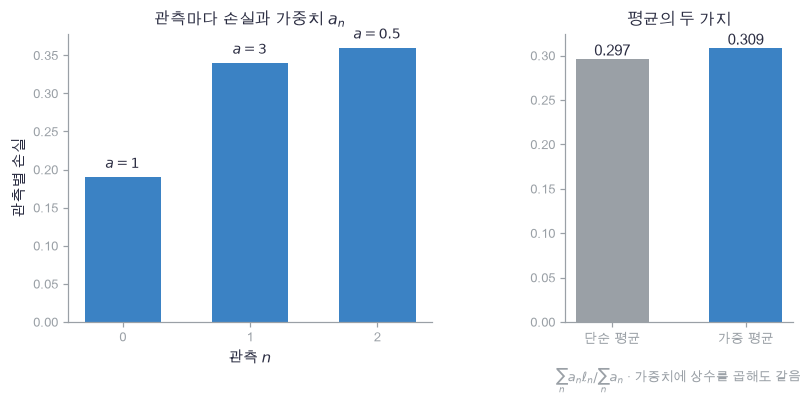

In [10]:
plot_weighted_mean(wm_per_obs, wm_weights, wm_plain, wm_weighted)

🔍 **확인** · 가중치 3인 관측 1의 손실이 가중 평균을 끌어올립니다. 가중치를 모두 7배 해도 분모가 같이 커져 값이 같습니다. 아래 구현은 이 평균의 계수 $a_n/(K\sum a)$를 원소별 미분에 곱해 기울기까지 냅니다.

In [11]:
def regression_loss(prediction, target, kind='huber', delta=.5, weights=None):
    """관측 가중 평균 손실 L = Σ_n a_n [mean_k ρ(r_nk)] / Σ_m a_m 과 예측의 기울기 a_n/(K Σa) ρ'(r_nk).
    prediction, target: (N, K), weights: (N,) 또는 None(모두 1) → (L: 숫자, d_prediction: (N, K))."""
    # 쓰는 것: element_loss (1절)
    if prediction.ndim != 2 or prediction.shape != target.shape:
        raise ValueError('예측과 정답을 같은 (N,K) 배열로 전달합니다.')
    N, K = prediction.shape
    weights = np.ones(N) if weights is None else np.asarray(weights, dtype=float)
    if weights.shape != (N,) or np.any(~np.isfinite(weights)) or np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError('관측별 비음수 가중치이며 총합은 양수입니다.')
    values, derivatives = element_loss(prediction - target, kind, delta)   # (N, K) 둘
    normalized = weights[:, None] / (weights.sum() * K)     # (N, 1): 원소마다 곱할 계수 a_n/(K Σa)
    return np.sum(normalized * values), normalized * derivatives

In [12]:
# 쓰는 것: wm_pred, wm_target, wm_weights, wm_weighted (2절 그림 셀)
prediction = np.array([[.2, -.8], [1.5, -.1], [.7, -1.2]])   # (3, 2)
target = np.array([[0., .1], [.2, .3], [-.1, -.2]])
weights = np.array([1., 3., .5])
loss_gradient_errors = {}
for kind in ['mse', 'mae', 'huber']:
    value, grad = regression_loss(prediction, target, kind, .6, weights)

    def loss_scalar():
        """검사기용: 이번 kind의 손실값."""
        return regression_loss(prediction, target, kind, .6, weights)[0]

    numeric = numerical_gradient(loss_scalar, prediction)   # prediction을 흔들어 잰 중심차분
    loss_gradient_errors[kind] = rel_error(grad, numeric)
    np.testing.assert_allclose(regression_loss(prediction, target, kind, .6, weights*7)[0], value)   # 검산: 가중치 7배에 불변
assert max(loss_gradient_errors.values()) < 1e-7, "세 손실의 가중 기울기가 중심차분과 1e−7 안에서 같아야 합니다"
print('가중 손실 기울기 상대 오차:', loss_gradient_errors)
np.testing.assert_allclose(regression_loss(wm_pred, wm_target, "huber", .6, wm_weights)[0], wm_weighted)   # 검산: 위 그림의 가중 평균과 같음

가중 손실 기울기 상대 오차: {'mse': 7.799658355076225e-11, 'mae': 1.3977802247034026e-10, 'huber': 1.1002213029520648e-10}


🔍 **확인** · 세 손실 모두 가중 기울기가 중심차분과 맞고, 가중치를 7배 해도 손실이 같습니다. 위 그림의 가중 평균도 같은 함수가 냅니다.

### ✏️ 연습 2 · 출력 축으로 평균, 관측은 가중 평균

원소별 손실 `values` `(N, K)`와 관측 가중치 `weights` `(N,)`에서, 관측마다 출력 $K$개를 평균낸 `per_obs` `(N,)`과 그것을 가중치로 가중 평균한 손실 `L` 두 줄을 채우세요. 어느 축을 먼저 없애는지, 분모가 무엇인지가 핵심입니다.

In [13]:
def exercise_weighted_mean(values, weights):
    """연습 2: 원소별 손실을 출력 축으로 평균낸 뒤 관측 가중 평균. values: (N, K), weights: (N,) → (per_obs: (N,), L: 숫자)."""
    assert values.ndim == 2, "values는 (N, K) 2차원이어야 합니다"
    assert weights.shape == (values.shape[0],), "weights는 관측 수와 같은 (N,)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 관측마다 출력 K개를 평균낸 per_obs (N,)와, 그것을 가중치로 가중 평균한 L = Σ a_n ℓ_n / Σ a_m (숫자)
    ### 힌트: 2절 그림 셀의 wm_per_obs, wm_weighted 두 줄입니다. axis에 적은 축이 사라지므로 (N, K)에서 관측 축만 남기려면 어느 축인지 고르고, 분모는 수식 Σ a_n ℓ_n / Σ a_m 을 보세요.
    raise NotImplementedError
    return per_obs, L

In [14]:
def check_weighted_mean(candidate):
    """(3, 2) 손계산 하나, 가중치 상수배, 모두 1인 가중치, 2절 그림 셀의 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: wm_values, wm_weights, wm_per_obs, wm_weighted (2절 그림 셀)
    example_values = np.array([[1., 3.], [2., 4.], [0., 6.]])    # (3, 2): 관측 3개 × 출력 2개의 원소별 손실
    example_weights = np.array([1., 2., 1.])                     # (3,)
    per_obs, L = candidate(example_values, example_weights)
    assert per_obs.shape == (3,), f"관측별 손실은 (N,) = (3,)이어야 하는데 {per_obs.shape}입니다"
    assert np.ndim(L) == 0, f"가중 평균은 숫자 하나여야 하는데 모양이 {np.shape(L)}입니다"
    np.testing.assert_allclose(per_obs, [2., 3., 3.])            # 검산: 행마다 출력 2개의 평균 [(1+3)/2, (2+4)/2, (0+6)/2]
    np.testing.assert_allclose(L, 2.75)                          # 검산: (1·2 + 2·3 + 1·3) / (1+2+1) = 11/4
    np.testing.assert_allclose(candidate(example_values, 7 * example_weights)[1], 2.75)   # 검산: 가중치 상수배에 불변
    np.testing.assert_allclose(candidate(example_values, np.ones(3))[1], example_values.mean())   # 검산: 모두 1이면 전체 원소 평균
    per_obs_wm, L_wm = candidate(wm_values, wm_weights)
    np.testing.assert_allclose(per_obs_wm, wm_per_obs)           # 검산: 2절 그림 셀의 관측별 손실
    np.testing.assert_allclose(L_wm, wm_weighted)                # 검산: 2절 그림 셀의 가중 평균
    print("평균 축과 가중 평균: 손계산과 일치합니다.")

run_check(check_weighted_mean, exercise_weighted_mean, hint="per_obs = values.mean(axis=1) · L = (weights * per_obs).sum() / weights.sum()")

☐ exercise_weighted_mean: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: per_obs = values.mean(axis=1) · L = (weights * per_obs).sum() / weights.sum()


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
per_obs = values.mean(axis=1)
L = (weights * per_obs).sum() / weights.sum()
```

</details>

## 🔑 3. L2를 붙인 선형 모델의 전체 미분

**이 절에서 가져갈 것:** 평균 데이터 손실에 $\frac\lambda2\|W\|^2$를 더하면 $dW=X^\top d\hat Y+\lambda W$입니다. 평균이 이미 데이터 손실에 들어 있으므로 $\lambda W$를 배치 크기로 다시 나누지 않습니다. 이 규약에서 half-MSE의 해는 ridge $(A^\top A+NK\lambda P)\theta=A^\top Y$입니다.

> **용어**
>
> - **정규화(regularization)·L2**: 목적에 파라미터의 크기 벌점 $\frac\lambda2\sum W^2$를 더하는 것. 큰 가중치를 피하게 합니다. 편향 $b$는 벌점에서 뺍니다.
> - **ridge**: half-MSE + L2의 닫힌 해. 정규방정식(11번)에 $NK\lambda P$를 더한 꼴입니다.

$\hat Y=XW+b$, $J=L_{data}+\tfrac\lambda2\sum_{d,k}W_{dk}^2$를 정합니다.
가중치에 대한 벌점을 추가한 **정규화(regularization)** 입니다. 이 예제에서는 $b$를 벌점에서 분리합니다.

$dW=X^Td\hat Y+\lambda W$, $db=\sum_nd\hat Y_n$입니다.
$L_{data}$가 평균이므로 $\lambda W$는 배치 크기에 따라 다시 나누지 않고 사용합니다.
표본마다 다른 가중치와 정규화는 서로 다른 항이며 각각의 계수를 기록합니다.

아래는 MNIST "7이면 1" half-MSE 회귀의 가중치를 L2 세기별 ridge 닫힌 해로 구한 것입니다. $A=[X,\mathbf 1]$, $P$는 $b$ 자리만 0인 대각행렬입니다.

> **코드**
>
> - `np.diag(np.append(np.ones(784), 0.))`: 1이 784개, 끝에 0 하나인 대각행렬 P. 편향 자리에만 벌점을 주지 않습니다.
> - `np.linalg.solve(A.T @ A + N·λ·P, A.T @ Y)`: ridge 정규방정식의 해(11번의 최소제곱에 벌점 항). `theta[:784, 0]`이 가중치, `theta[784, 0]`이 편향입니다.
> - `loss_fn=regression_loss`: 손실 함수를 인자로 받아 기본값은 본문 것. 6절에서 다른 손실을 끼워 검사합니다.
> - `np.vstack([W, b])`: 가중치 `(D, K)` 아래에 편향 `(K,)`을 행으로 붙여 ridge 해 θ = [W; b]와 모양을 맞춥니다.

In [15]:
# 쓰는 것: mnist_X, mnist_T (📎 데이터 셀)
ridge_A = np.column_stack([mnist_X, np.ones(len(mnist_X))])           # (5000, 785): [X, 1]
ridge_P = np.diag(np.append(np.ones(784), 0.))                          # (785, 785): b 자리만 벌점 없음
ridge_lambdas = [0.0001, 0.01, 0.1]
ridge_images, ridge_w_norms, ridge_errors = [], [], []                  # λ마다 가중치 이미지, 길이, 학습 오차
for lam in ridge_lambdas:
    theta = np.linalg.solve(ridge_A.T @ ridge_A + len(ridge_A) * 1 * lam * ridge_P, ridge_A.T @ mnist_T)   # (785, 1): ridge 닫힌 해 (N·K·λ, K = 1)
    w_img, b_val = theta[:784, 0], theta[784, 0]                        # (784,) 가중치, 편향
    ridge_images.append(w_img.reshape(28, 28))
    ridge_w_norms.append(float(np.linalg.norm(w_img)))
    ridge_errors.append(float(0.5 * np.mean((mnist_X @ w_img + b_val - mnist_T[:, 0]) ** 2)))   # 학습 half-MSE
print("λ:", ridge_lambdas, "\n‖w‖:", np.round(ridge_w_norms, 3), "\n학습 half-MSE:", np.round(ridge_errors, 5))

λ: [0.0001, 0.01, 0.1] 
‖w‖: [1.852 0.442 0.215] 
학습 half-MSE: [0.01477 0.01615 0.0183 ]


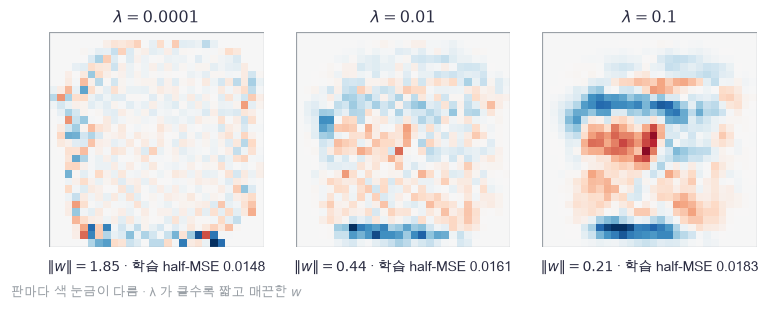

In [16]:
plot_l2_templates(ridge_images, ridge_lambdas, ridge_w_norms, ridge_errors)

🔍 **확인** · $\lambda$가 아주 작으면 5,000장을 거의 그대로 맞추느라 화소마다 요동하고 길이가 큽니다. $\lambda$를 키울수록 가중치가 짧아지고 7의 가로획·세로획 모양이 매끈하게 남습니다. 학습 오차는 조금 커집니다.
어느 $\lambda$가 새 데이터에서 좋은지는 15번의 분할·평가로 정합니다. 아래 구현은 가중 손실 + L2의 목적·기울기와 경사하강 학습 루프입니다.

📎 $\lambda=0$은 여기서 풀 수 없습니다. 가장자리 화소가 항상 0이라 $A^\top A$가 특이행렬이기 때문이고, 작은 $\lambda$가 그 방향을 잡아 줍니다.

In [17]:
def linear_objective(X, Y, W, b, kind='huber', delta=.5, weights=None, l2=0., loss_fn=regression_loss):
    """선형 모델의 목적 J = L_data(XW + b, Y) + (λ/2)Σ W² 과 기울기 dW = Xᵀ dŶ + λW, db = Σ_n dŶ.
    X: (N, D), Y: (N, K), W: (D, K), b: (K,) → (J: 숫자, dW: (D, K), db: (K,))."""
    # 쓰는 것: regression_loss (2절)
    data_loss, d_prediction = loss_fn(X @ W + b, Y, kind, delta, weights)   # 평균이 이미 들어 있는 데이터 손실과 dŶ
    objective = data_loss + .5 * l2 * np.sum(W**2)          # L2 벌점 (b 제외)
    dW = X.T @ d_prediction + l2 * W                        # (D, K): 데이터 항 + λW (배치 크기로 다시 나누지 않음)
    db = d_prediction.sum(axis=0)                           # (K,)
    return objective, dW, db


def fit_linear(X, Y, kind, delta=.5, weights=None, l2=0., steps=1200, lr=.04, loss_fn=regression_loss):
    """선형 모델을 경사하강으로 steps번 갱신 (0에서 시작). → (W, b, 목적 기록 (steps+1,))."""
    W, b = np.zeros((X.shape[1], Y.shape[1])), np.zeros(Y.shape[1])
    history = []
    for step in range(steps):
        objective, dW, db = linear_objective(X, Y, W, b, kind, delta, weights, l2, loss_fn)
        history.append(objective)
        W -= lr * dW
        b -= lr * db
    history.append(linear_objective(X, Y, W, b, kind, delta, weights, l2, loss_fn)[0])   # 마지막 갱신 뒤의 목적
    return W, b, np.array(history)

In [18]:
rng = np.random.default_rng(140)                            # 이 노트북의 검산·데이터용 난수 생성기. 5절도 이어 씁니다
X_check, Y_check = rng.normal(size=(5, 3)), rng.normal(size=(5, 2))   # (N, D), (N, K)
W_check, b_check = rng.normal(size=(3, 2)), rng.normal(size=2)
weights_check = np.array([1., 0., 3., .2, 2.])              # (5,): 가중치 0인 관측 포함
objective, dW, db = linear_objective(X_check, Y_check, W_check, b_check, weights=weights_check, l2=.3)


def objective_scalar():
    """검사기용: 목적값 J (가중 Huber + L2)."""
    return linear_objective(X_check, Y_check, W_check, b_check, weights=weights_check, l2=.3)[0]


linear_gradient_errors = [rel_error(analytic, numerical_gradient(objective_scalar, parameter))
                          for analytic, parameter in [(dW, W_check), (db, b_check)]]   # dW, db를 중심차분과 대조
assert max(linear_gradient_errors) < 1e-7, "dW, db의 상대오차가 1e−7 아래여야 합니다"
print('가중 Huber + L2 전체 미분 상대 오차:', max(linear_gradient_errors))

가중 Huber + L2 전체 미분 상대 오차: 2.793343126683725e-10


🔍 **확인** · 관측 가중치(0인 관측 포함)와 L2를 함께 둔 목적의 $dW, db$가 중심차분과 맞습니다.

### 🔍 완성 예제: 같은 이상치에 세 손실 적용하기

학습 관측 80개에 $y=2x+.4+\text{작은 잡음}$을 만들고 10개의 관측에 큰 양의 오차를 더합니다.
세 모델의 초기값·학습률·스텝을 같게 둡니다. 평가에는 별도로 만든 깨끗한 함수값의 **RMSE** $\sqrt{\operatorname{mean}(r^2)}$를 사용합니다.
이 데이터는 큰 오차의 영향을 관찰하기 위한 합성 예제입니다.

In [19]:
# 쓰는 것: rng (3절 검산 셀) · fit_linear (3절)
X_train = np.linspace(-1, 1, 80)[:, None]                   # (80, 1): 학습 입력
Y_train = 2*X_train + .4 + rng.normal(size=(80, 1)) * .06   # (80, 1): 직선 + 작은 잡음
outlier_indices = np.arange(50, 70, 2)                      # (10,): 이상치로 만들 관측 번호
Y_train[outlier_indices] += 7.                              # 큰 양의 오차
X_clean = np.linspace(-1.2, 1.2, 160)[:, None]              # (160, 1): 평가용 입력
Y_clean = 2*X_clean + .4                                    # (160, 1): 잡음 없는 참 함수값
models, rmse_by_loss = {}, {}
for kind in ['mse', 'mae', 'huber']:                        # 같은 초기값·학습률·스텝으로 세 손실
    W, b, history = fit_linear(X_train, Y_train, kind, delta=.3)
    models[kind] = (W, b, history)
    rmse_by_loss[kind] = np.sqrt(np.mean((X_clean @ W + b - Y_clean)**2))   # 깨끗한 함수값과의 RMSE
    print(kind, '기울기/절편:', W.item(), b.item(), '깨끗한 함수 RMSE:', rmse_by_loss[kind])
assert rmse_by_loss['huber'] < rmse_by_loss['mse'], "이 이상치 데이터에서 Huber의 RMSE가 MSE보다 작아야 합니다"

mse 기울기/절편: 3.252771095137692 1.2682392167877086 깨끗한 함수 RMSE: 1.2315210814748556
mae 기울기/절편: 1.9986202531645565 0.4130000000000003 깨끗한 함수 RMSE: 0.01303553875695721
huber 기울기/절편: 2.0571234851654476 0.4412893343627832 깨끗한 함수 RMSE: 0.057365453459457774


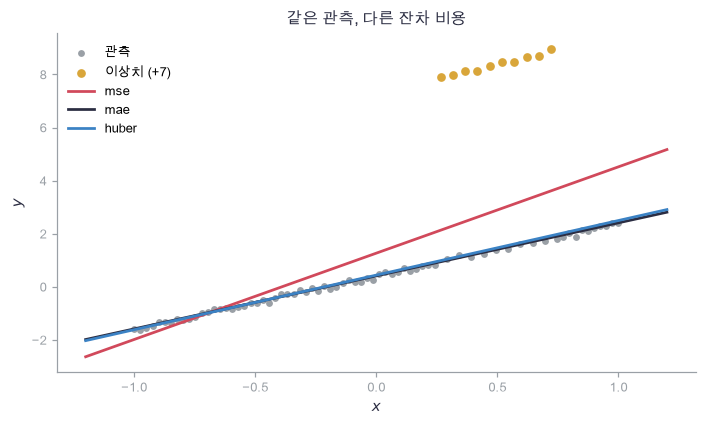

In [20]:
plot_outlier_fits(X_train.ravel(), Y_train.ravel(), X_clean.ravel(), {kind: (X_clean @ W + b).ravel() for kind, (W, b, _) in models.items()}, outlier_indices)

🔍 **확인** · MSE는 큰 양의 오차를 줄이는 쪽으로 직선을 움직였습니다. Huber·MAE는 큰 잔차의 기울기를 제한합니다.
이 결과는 이 관측 생성 방식에서 비교한 수치입니다. 큰 값 자체가 예측 대상의 중요한 신호라면 그 관측 가정을 평가 데이터에도 반영합니다.

### 🔍 L2의 계수와 해석해 비교

half-MSE 선형 모델에서 $A=[X,1]$, $\theta=[W;b]$를 쓰면
$(A^TA+NK\lambda P)\theta=A^TY$입니다. $P$는 $W$ 자리에 1, $b$ 자리에 0인 대각행렬입니다.
출력 수가 $K$이고 데이터 손실이 $NK$개 원소의 평균이므로 계수는 $NK\lambda$입니다. 아래 첫 비교는 $K=1$이며, 이어서 $K=2$도 검산합니다. 이것은 정규화된 최소제곱인 ridge의 해입니다. 기울기 학습이 같은 목적의 해로 가는지 대조합니다.

In [21]:
# 쓰는 것: rng (3절 검산 셀) · fit_linear (3절)
X_ridge = rng.normal(size=(60, 3))                          # (60, 3)
Y_ridge = X_ridge @ np.array([[1.], [-2.], [.5]]) + .4 + rng.normal(size=(60, 1)) * .1   # (60, 1): 선형 + 잡음
ridge_norms = []
for l2 in [0., .1, 1.]:
    W, b, _ = fit_linear(X_ridge, Y_ridge, 'mse', l2=l2, steps=1500)   # 경사하강 해
    A = np.column_stack([X_ridge, np.ones(len(X_ridge))])   # (60, 4): [X, 1]
    penalty = np.diag([1., 1., 1., 0.])                     # b 자리만 벌점 없음
    exact = np.linalg.solve(A.T @ A + len(A)*Y_ridge.shape[1]*l2*penalty, A.T @ Y_ridge)   # (4, 1): ridge 닫힌 해 (계수 NKλ)
    np.testing.assert_allclose(np.vstack([W, b]), exact, atol=1e-10)   # 검산: 경사하강 = 닫힌 해
    ridge_norms.append(np.linalg.norm(W))
print('lambda=0,0.1,1의 가중치 길이:', ridge_norms)
Y_multi = np.column_stack([Y_ridge[:, 0], -.3*Y_ridge[:, 0]+.7])   # (60, 2): 출력 K = 2
W_multi, b_multi, _ = fit_linear(X_ridge, Y_multi, 'mse', l2=.4, steps=2000)
exact_multi = np.linalg.solve(A.T @ A + len(A)*Y_multi.shape[1]*.4*penalty, A.T @ Y_multi)   # 계수 N·2·λ
np.testing.assert_allclose(np.vstack([W_multi, b_multi]), exact_multi, atol=1e-10)   # 검산: K = 2에서도 같음
print('K=2 ridge 해와 학습값의 최대 절대차:', np.max(np.abs(np.vstack([W_multi, b_multi])-exact_multi)))

lambda=0,0.1,1의 가중치 길이: [np.float64(2.275587957068822), np.float64(2.104915903400096), np.float64(1.2567949361416186)]


K=2 ridge 해와 학습값의 최대 절대차: 2.886579864025407e-15


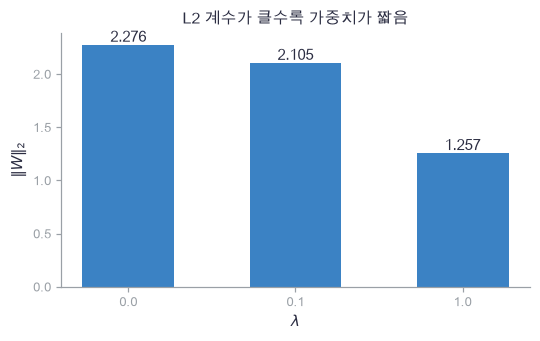

In [22]:
plot_ridge_norms([0., .1, 1.], ridge_norms)

🔍 **확인** · 경사하강으로 학습한 $W, b$가 ridge 닫힌 해와 $10^{-10}$ 안에서 같고, $K=2$에서도 계수 $NK\lambda$가 맞습니다. $\lambda$가 클수록 가중치 길이가 짧습니다. 3절의 MNIST 그림도 같은 닫힌 해로 그린 것입니다.

### ✏️ 연습 3 · λ 앞에 무엇이 붙을까

$A=[X,\mathbf 1]$ `(N, D+1)`, 정답 `Y` `(N, K)`, 계수 `l2`, 편향 자리만 0인 대각행렬 `P`에서 ridge 닫힌 해 $\theta=[W;b]$를 구하는 한 줄을 채우세요. 데이터 손실이 원소 $NK$개의 평균이라는 것이 $\lambda$ 앞의 계수를 정합니다. 검사는 점 3개의 손계산을 출력 1개와 2개에서 각각 보고, 3절의 경사하강 해와도 맞춥니다.

In [23]:
def exercise_ridge_solve(A, Y, l2, P):
    """연습 3: 평균 half-MSE + L2의 ridge 닫힌 해. A: (N, D+1) = [X, 1], Y: (N, K), P: (D+1, D+1) → theta: (D+1, K)."""
    assert A.shape[0] == Y.shape[0], "A와 Y의 관측 수 N이 같아야 합니다"
    assert P.shape == (A.shape[1], A.shape[1]), "P는 (D+1, D+1) 대각행렬이어야 합니다"
    N, K = A.shape[0], Y.shape[1]                       # 관측 수와 출력 수
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 정규방정식 AᵀAθ = AᵀY 의 왼쪽에 벌점 항 λP를 평균 규약에 맞는 배수로 더해 풀어 낸 theta = [W; b] (모양 (D+1, K))
    ### 힌트: 3절 ridge 비교 셀의 np.linalg.solve 한 줄입니다. 수식의 λ가 인자 l2이고, 배수는 미리 구해 둔 N, K로 만듭니다.
    raise NotImplementedError
    return theta

In [24]:
def check_ridge_solve(candidate):
    """점 3개 손계산을 출력 1개·2개에서 보고 3절 경사하강 해와도 비교합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: X_ridge, Y_ridge, Y_multi, W_multi, b_multi (3절 ridge 비교 셀) · fit_linear (3절)
    example_A = np.array([[1., 1.], [2., 1.], [3., 1.]])          # (3, 2): x = 1, 2, 3에 상수 열
    example_Y = np.array([[1.], [2.], [3.]])                      # (3, 1): 정확히 y = x 위의 점
    example_P = np.diag([1., 0.])                                 # b 자리만 벌점 없음
    theta = candidate(example_A, example_Y, 1., example_P)
    assert theta.shape == (2, 1), f"theta는 (D+1, K) = (2, 1)이어야 하는데 {theta.shape}입니다"
    np.testing.assert_allclose(theta, [[.4], [1.2]])              # 검산: AᵀA = [[14, 6], [6, 3]]의 (0, 0)에 벌점 3을 더해 [[17, 6], [6, 3]]θ = [14, 6]ᵀ
    np.testing.assert_allclose(candidate(example_A, example_Y, 0., example_P), [[1.], [0.]], atol=1e-12)   # 검산: λ = 0이면 최소제곱 y = x
    example_Y2 = np.column_stack([example_Y[:, 0], example_Y[:, 0] - 1.])   # (3, 2): 출력 둘
    np.testing.assert_allclose(candidate(example_A, example_Y2, 1., example_P), [[.25, .25], [1.5, .5]])   # 검산: 출력이 둘이면 벌점도 두 배 6 → [[20, 6], [6, 3]]θ = [[14, 8], [6, 3]]
    W_gd, b_gd, _ = fit_linear(X_ridge, Y_ridge, "mse", l2=.1, steps=1500)   # 3절 데이터의 경사하강 해
    A_ridge = np.column_stack([X_ridge, np.ones(len(X_ridge))])   # (60, 4)
    penalty_ridge = np.diag([1., 1., 1., 0.])                     # b 자리만 벌점 없음
    np.testing.assert_allclose(candidate(A_ridge, Y_ridge, .1, penalty_ridge), np.vstack([W_gd, b_gd]), atol=1e-10)   # 검산: 경사하강 = 닫힌 해
    np.testing.assert_allclose(candidate(A_ridge, Y_multi, .4, penalty_ridge), np.vstack([W_multi, b_multi]), atol=1e-10)   # 검산: 3절의 K = 2 해와도 같음
    print("ridge 닫힌 해: 손계산·경사하강과 일치합니다.")

run_check(check_ridge_solve, exercise_ridge_solve, hint="theta = np.linalg.solve(A.T @ A + N * K * l2 * P, A.T @ Y)")

☐ exercise_ridge_solve: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: theta = np.linalg.solve(A.T @ A + N * K * l2 * P, A.T @ Y)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
theta = np.linalg.solve(A.T @ A + N * K * l2 * P, A.T @ Y)
```

</details>

## 🔑 4. Adam의 L2와 AdamW의 감쇠를 한 스텝씩 보기

**이 절에서 가져갈 것:** SGD에서는 목적의 L2 기울기 $\lambda W$와 별도의 감쇠 $(1-\eta\lambda)W$가 같은 갱신입니다. Adam에서는 다릅니다. L2를 손실에 넣으면 $g+\lambda W$가 상태 $m, v$에 들어가 정규화되지만, AdamW는 데이터 기울기 $g$만 상태에 넣고 감쇠를 따로 곱합니다.

> **용어**
>
> - **가중치 감쇠(weight decay)**: 갱신마다 $W$에 $(1-\eta\lambda)$를 곱해 조금씩 줄이는 것. SGD에서는 L2 기울기와 같은 효과입니다.
> - **AdamW**: 감쇠를 Adam의 적응적 정규화 밖에 둔 규약. 상태에는 데이터 기울기만 들어갑니다.

상태 없는 SGD에서는
$W-\eta(g+\lambda W)=(1-\eta\lambda)W-\eta g$입니다.
목적의 L2 기울기와 별도 가중치 감쇠가 같은 갱신을 만듭니다.

Adam에서 L2를 손실에 넣으면 $g+\lambda W$가 1차·2차 모멘트 상태 $m,v$에 들어갑니다.
**AdamW**는 데이터 기울기 $g$로 Adam 상태를 계산하고

$$W_{t+1}=(1-\eta\lambda)W_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

로 갱신합니다. $\hat m_t=m_t/(1-\beta_1^t)$, $\hat v_t=v_t/(1-\beta_2^t)$이며 $t$는 1부터 시작합니다.
두 방법이 어디서 달라지는지 고정된 기울기 입력으로 확인합니다. 여기의 감쇠 계수 $\lambda$는 갱신 규약의 계수입니다.

아래는 $W_0=(1, 10)$, 데이터 기울기 $g=(0.2, -0.1)$, $\eta=0.03$, $\lambda=0.05$의 첫 스텝을 세 방식으로 손계산한 것입니다. 첫 스텝에서 Adam의 $\hat m/\sqrt{\hat v}$는 기울기의 부호입니다.

> **코드**
>
> - `g / (np.abs(g) + 1e-8)`: 첫 스텝의 m̂/√v̂. m̂ = g, v̂ = g²이라 부호(±1)만 남습니다.
> - `(1 - lr * decay) * W`: 별도 감쇠. 상태와 무관하게 W를 조금 줄입니다.
> - `state = (m, v, t)`: Adam 상태를 튜플로. `m, v, t = state`로 풀고 새 튜플을 돌려줍니다.
> - `enumerate([g1, g2], start=1)`: 스텝 번호를 1부터 세며 기울기를 돕니다.

In [25]:
step_W0, step_g = np.array([1., 10.]), np.array([.2, -.1])            # (2,) 둘: 시작 가중치, 데이터 기울기
step_lr, step_decay = .03, .05                                        # η, λ
step_sgd = step_W0 - step_lr * (step_g + step_decay * step_W0)                                      # SGD + L2 = 감쇠
step_coupled_g = step_g + step_decay * step_W0                                                      # Adam + L2: 상태에 들어가는 기울기
step_coupled = step_W0 - step_lr * step_coupled_g / (np.abs(step_coupled_g) + 1e-8)                 # 첫 스텝: m̂/√v̂ = 부호
step_decoupled = (1 - step_lr * step_decay) * step_W0 - step_lr * step_g / (np.abs(step_g) + 1e-8)   # AdamW: 데이터 기울기만 상태에
print("Adam+L2 가 상태에 넣는 기울기:", step_coupled_g, "(둘째 좌표 부호가 데이터 기울기와 반대)")
print("첫 스텝 이동 · SGD+L2:", (step_sgd - step_W0).round(4), "· Adam+L2:", (step_coupled - step_W0).round(4), "· AdamW:", (step_decoupled - step_W0).round(4))

Adam+L2 가 상태에 넣는 기울기: [0.25 0.4 ] (둘째 좌표 부호가 데이터 기울기와 반대)
첫 스텝 이동 · SGD+L2: [-0.0075 -0.012 ] · Adam+L2: [-0.03 -0.03] · AdamW: [-0.0315  0.015 ]


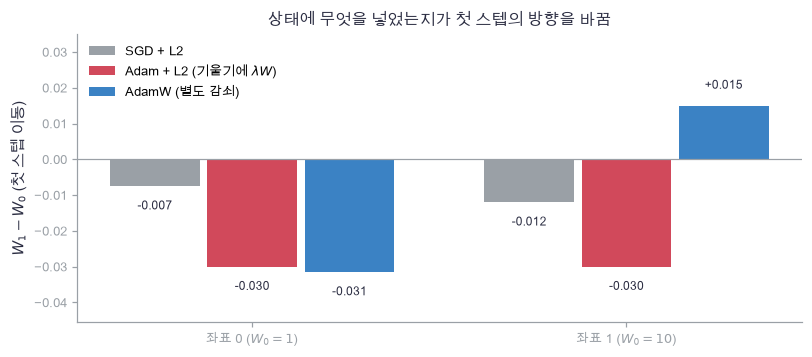

In [26]:
plot_decay_comparison(step_W0, step_sgd, step_coupled, step_decoupled)

🔍 **확인** · 둘째 좌표에서 데이터 기울기는 $-0.1$(늘리는 방향)인데 $W=10$이 커서 $\lambda W=0.5$가 더 큽니다. Adam+L2는 그 합 $+0.4$의 **부호**만 보고 $W$를 줄이고, AdamW는 데이터 기울기의 부호대로 늘린 뒤 감쇠로 조금 줄입니다. 상태에 무엇을 넣었는지가 방향을 바꿉니다.
아래 구현은 감쇠 계수를 받는 Adam 한 스텝이고, 검산에서 이 손계산과 두 스텝 손계산을 봅니다.

In [27]:
def adam_step(W, gradient, state, lr=.03, beta1=.5, beta2=.75, eps=1e-8, weight_decay=0.):
    """Adam 한 스텝 (04번 6절)에 별도 감쇠를 더한 AdamW: W ← (1 − ηλ)W − η m̂/(√v̂ + ε). weight_decay = 0이면 Adam.
    state: (m, v, t) → (새 W, 새 state)."""
    m, v, t = state
    t = t + 1                                               # 1부터 세는 스텝 수
    m = beta1*m + (1-beta1)*gradient                        # 1차 모멘트 (데이터 기울기만)
    v = beta2*v + (1-beta2)*gradient**2                     # 2차 모멘트
    m_hat, v_hat = m/(1-beta1**t), v/(1-beta2**t)           # 편향 보정
    updated = (1-lr*weight_decay)*W - lr*m_hat/(np.sqrt(v_hat)+eps)   # 감쇠는 상태 밖에서 곱함
    return updated, (m, v, t)

In [28]:
# 쓰는 것: step_coupled, step_decoupled (4절 그림 셀)
W0, gradient = np.array([1., 10.]), np.array([.2, -.1])
lr, decay = .03, .05
np.testing.assert_allclose(W0-lr*(gradient+decay*W0), (1-lr*decay)*W0-lr*gradient)   # 검산: SGD에서는 L2 기울기 = 감쇠
zero_state = (np.zeros(2), np.zeros(2), 0)                  # m = v = 0, t = 0
W_coupled, coupled_state = adam_step(W0, gradient+decay*W0, zero_state, lr=lr)             # Adam + L2: λW를 기울기에 넣음
W_decoupled, decoupled_state = adam_step(W0, gradient, zero_state, lr=lr, weight_decay=decay)   # AdamW: 감쇠를 따로
expected_decoupled = (1-lr*decay)*W0-lr*gradient/(np.abs(gradient)+1e-8)   # 손계산: 첫 스텝은 부호
np.testing.assert_allclose(W_decoupled, expected_decoupled)     # 검산: AdamW 첫 스텝 손계산
assert not np.allclose(W_coupled, W_decoupled), "두 방식의 첫 스텝이 달라야 합니다"
np.testing.assert_allclose(decoupled_state[0], .5*gradient)     # 검산: m₁ = (1 − β₁)g, 데이터 기울기만 상태에
print('Adam + L2:', W_coupled, 'AdamW:', W_decoupled)
np.testing.assert_allclose(W_coupled, step_coupled)         # 검산: 위 그림의 첫 스텝과 같음
np.testing.assert_allclose(W_decoupled, step_decoupled)   # 검산: AdamW도 같음

Adam + L2: [0.97 9.97] AdamW: [ 0.9685 10.015 ]


🔍 **확인** · 첫 스텝의 두 번째 좌표에서 L2를 포함한 기울기는 양수이고 데이터 기울기는 음수입니다. 상태에 무엇을 넣었는지가 갱신 방향에 드러납니다.

아래 손계산 검사는 서로 다른 $\beta_1,\beta_2$, 두 스텝, 작은 기울기, 큰 $\epsilon$을 사용합니다.
이 조건에서 bias correction·제곱근·epsilon 위치와 감쇠 적용을 함께 확인합니다.

In [29]:
test_w = np.array([1.2, -.7])
state = (np.zeros(2), np.zeros(2), 0)
manual_m, manual_v = np.zeros(2), np.zeros(2)               # 손으로 쓴 모멘트
for t, g in enumerate([np.array([2., 1e-9]), np.array([-1., 2e-9])], start=1):   # 두 스텝. 둘째 좌표는 아주 작은 기울기
    manual_m = .5*manual_m + .5*g                           # β₁ = 0.5
    manual_v = .75*manual_v + .25*g*g                       # β₂ = 0.75
    expected = .98*test_w - .1*(manual_m/(1-.5**t))/(np.sqrt(manual_v/(1-.75**t))+.03)   # (1 − 0.1·0.2)W − η m̂/(√v̂ + 0.03)
    actual, state = adam_step(test_w, g, state, lr=.1, beta1=.5, beta2=.75, eps=.03, weight_decay=.2)
    np.testing.assert_allclose(actual, expected, atol=1e-14)   # 검산: 보정·제곱근·ε 위치·감쇠가 손계산과 같음
    test_w = actual
print('AdamW 두 스텝 손계산 통과:', test_w)

AdamW 두 스텝 손계산 통과: [ 1.05592828 -0.67228001]


### ✏️ 연습 4 · λW를 상태에 넣을까, 밖에서 곱할까

시작 가중치 `W`, 데이터 기울기 `g`, 학습률 `lr`, 감쇠 계수 `decay`에서 본문 `adam_step`을 두 번 불러 Adam + L2의 첫 스텝 `coupled`와 AdamW의 첫 스텝 `decoupled`를 만드는 두 줄을 채우세요. 차이는 $\lambda W$를 어느 인자에 주느냐뿐입니다. 검사는 둘째 좌표의 방향이 갈리는 4절 손계산으로 합니다.

In [30]:
def exercise_coupled_vs_decoupled(W, g, lr, decay):
    """연습 4: 같은 adam_step으로 Adam + L2와 AdamW의 첫 스텝을 각각. W, g: (D,), lr·decay: 숫자 → (coupled: (D,), decoupled: (D,))."""
    assert W.shape == g.shape, "W와 g는 같은 모양 (D,)이어야 합니다"
    zero_state = (np.zeros_like(W), np.zeros_like(W), 0)   # m = v = 0, t = 0: 두 방식 모두 여기서 시작
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: L2 기울기 decay·W를 기울기에 더해 상태에 넣은 coupled와, 데이터 기울기 g만 넣고 감쇠를 weight_decay 인자로 따로 준 decoupled
    ### 힌트: 4절 검산 셀의 adam_step 호출 두 줄입니다. 돌려주는 새 state는 쓰지 않습니다. 수식의 λ가 인자 decay, η가 lr입니다.
    raise NotImplementedError
    return coupled, decoupled

In [31]:
def check_coupled_vs_decoupled(candidate):
    """4절 첫 스텝 손계산 W₀ = (1, 10), g = (0.2, −0.1)과 그림 셀의 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: step_W0, step_g, step_lr, step_decay, step_coupled, step_decoupled (4절 그림 셀)
    example_W, example_g = np.array([1., 10.]), np.array([.2, -.1])   # (2,) 둘
    coupled, decoupled = candidate(example_W, example_g, .03, .05)
    assert coupled.shape == (2,), f"갱신된 W는 (D,) = (2,)이어야 하는데 {coupled.shape}입니다"
    np.testing.assert_allclose(coupled, [.97, 9.97])              # 검산: 첫 스텝은 부호만. g + λW = (0.25, 0.4) → 둘 다 −0.03
    np.testing.assert_allclose(decoupled, [.9685, 10.015])        # 검산: (1 − 0.0015)·W − 0.03·sign(g) = (0.9985 − 0.03, 9.985 + 0.03)
    assert coupled[1] < example_W[1] < decoupled[1], "둘째 좌표에서 Adam + L2는 줄이고 AdamW는 늘려야 합니다"
    coupled_ref, decoupled_ref = candidate(step_W0, step_g, step_lr, step_decay)
    np.testing.assert_allclose(coupled_ref, step_coupled)         # 검산: 4절 그림 셀의 Adam + L2 첫 스텝
    np.testing.assert_allclose(decoupled_ref, step_decoupled)     # 검산: 4절 그림 셀의 AdamW 첫 스텝
    print("Adam + L2와 AdamW의 첫 스텝: 손계산과 일치합니다.")

run_check(check_coupled_vs_decoupled, exercise_coupled_vs_decoupled, hint="coupled, _ = adam_step(W, g + decay * W, zero_state, lr=lr) · decoupled, _ = adam_step(W, g, zero_state, lr=lr, weight_decay=decay)")

☐ exercise_coupled_vs_decoupled: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: coupled, _ = adam_step(W, g + decay * W, zero_state, lr=lr) · decoupled, _ = adam_step(W, g, zero_state, lr=lr, weight_decay=decay)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
coupled, _ = adam_step(W, g + decay * W, zero_state, lr=lr)
decoupled, _ = adam_step(W, g, zero_state, lr=lr, weight_decay=decay)
```

</details>

## 🔑 5. dropout: mask를 고정해서 미분하고 평균으로 해석하기

**이 절에서 가져갈 것:** inverted dropout은 원소마다 확률 $q$로 남기고 $1/q$를 곱해 평균을 원래대로 유지합니다. mask를 고정하면 backward는 $G\odot M/q$이고, 선형 모델의 제곱 손실에서 모든 mask의 평균 목적은 원래 손실에 L2 모양의 분산 항을 더한 것입니다.

> **용어**
>
> - **dropout·유지 확률** $q$: 학습 중 각 원소를 확률 $1-q$로 0으로 만드는 것. 평가 때는 끕니다.
> - **inverted dropout**: 남긴 원소에 $1/q$를 곱해 $\mathbb E[\tilde H\mid H]=H$가 되게 하는 규약. 코드에서는 `(rng.random(H.shape) < q) / q`.

각 원소에 대해 $M_{ij}\sim Bernoulli(q)$를 독립으로 뽑고
$\tilde H=H\odot M/q$로 계산합니다. $q$는 **유지 확률**입니다.
이것이 inverted dropout이며 $\mathbb E[\tilde H\mid H]=H$가 됩니다.
평가 단계에서는 $H$를 그대로 전달합니다. 학습 단계에 $1/q$ 배율을 적용한 규약입니다.

mask를 고정했을 때 $dH=G\odot M/q$입니다. 수치미분 중 같은 mask를 사용해야 같은 함수의 기울기를 비교하게 됩니다.
비선형 함수 $f$ 뒤에서는 일반적으로 $\mathbb E[f(\tilde H)]$와 $f(H)$가 달라집니다.

아래는 7 이미지에 $q=0.7$의 mask를 씌운 세 장과, mask 2,000개의 평균입니다.

> **코드**
>
> - `(rng.random(H.shape) < q) / q`: 0–1 균등 난수가 q보다 작은 자리만 True(확률 q) → 1/0으로 바뀌어 q로 나누면 1/q 또는 0인 배율 M/q.
> - `[mnist_7 * … for _ in range(3)]`: 다른 난수로 mask 세 장. `np.mean([...], axis=0)`은 2,000장을 쌓아 자리마다 평균.
> - `(m > 0).sum() / (mnist_7 > 0).sum()`: 살아남은 잉크 화소의 비율.

In [32]:
# 쓰는 것: mnist_7 (📎 데이터 셀)
drop_q = 0.7                                                # 유지 확률 q
drop_rng = np.random.default_rng(1400)
drop_masked = [mnist_7 * (drop_rng.random(mnist_7.shape) < drop_q) / drop_q for _ in range(3)]    # (28, 28) 세 장: 남긴 화소는 1/q배
drop_mean = np.mean([mnist_7 * (drop_rng.random(mnist_7.shape) < drop_q) / drop_q for _ in range(2000)], axis=0)   # (28, 28): mask 2,000개의 평균
print("살아남은 화소 비율:", [round(float((m > 0).sum() / (mnist_7 > 0).sum()), 3) for m in drop_masked],
      "· 평균과 원본의 최대 차이", np.abs(drop_mean - mnist_7).max().round(3))

살아남은 화소 비율: [0.687, 0.747, 0.711] · 평균과 원본의 최대 차이 0.05


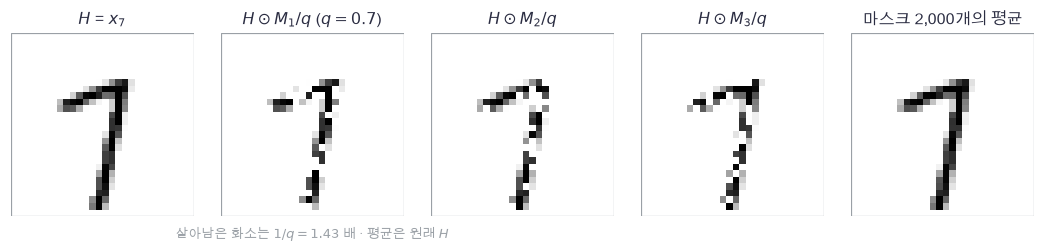

In [33]:
plot_dropout_masks(mnist_7, drop_masked, drop_mean, drop_q, 2000)

🔍 **확인** · mask마다 7의 획이 다른 자리에서 빠지고, 남은 화소는 $1/0.7$배로 진해집니다. 2,000개를 평균내면 원본 7이 돌아옵니다. 그것이 $1/q$를 곱하는 이유입니다.
아래 구현은 학습·평가 모드를 구분한 forward와 mask를 그대로 곱하는 backward입니다.

In [34]:
def dropout_forward(H, keep_probability, rng, training=True):
    """inverted dropout forward: 학습 때 H ⊙ M/q (M ~ Bernoulli(q)), 평가 때 H 그대로. → (출력, 배율 M/q)."""
    if not 0 < keep_probability <= 1:
        raise ValueError('유지 확률 q는 0보다 크고 1 이하입니다.')
    if not training:
        return H.copy(), np.ones_like(H)                    # 평가 모드: 배율 1
    multiplier = (rng.random(H.shape) < keep_probability).astype(float) / keep_probability   # (H 모양): 1/q 또는 0
    return H * multiplier, multiplier


def dropout_backward(G, multiplier):
    """mask를 고정한 backward: dH = G ⊙ M/q. G: 상류 기울기, multiplier: forward의 배율 → 같은 모양."""
    return G * multiplier

In [35]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · rng (3절 검산 셀) · drop_q, drop_masked (5절 그림 셀)
H = np.array([[1., -2., .5], [3., .4, -1.]])                # (2, 3)
G = rng.normal(size=H.shape)                                # 임의의 상류 기울기
dropped, multiplier = dropout_forward(H, .7, rng)
dH = dropout_backward(G, multiplier)


def dropout_scalar():
    """검사기용: 같은 mask를 쓴 스칼라 L = Σ (H ⊙ M/q) ⊙ G."""
    return np.sum(H*multiplier*G)


dropout_error = rel_error(dH, numerical_gradient(dropout_scalar, H))   # H를 흔들어 잰 중심차분과 비교 (mask 고정)
assert dropout_error < 1e-7, "고정 mask의 미분이 중심차분과 1e−7 안에서 같아야 합니다"
np.testing.assert_allclose(dropout_forward(H, .7, rng, training=False)[0], H)   # 검산: 평가 모드는 그대로
np.testing.assert_allclose(dropout_forward(H, 1., rng)[0], H)                   # 검산: q = 1도 그대로
monte_carlo_output = np.stack([dropout_forward(H, .7, rng)[0] for _ in range(10000)]).mean(axis=0)   # mask 10,000개의 평균 출력
np.testing.assert_allclose(monte_carlo_output, H, atol=.07)                     # 검산: E[H̃] = H
print('dropout 고정 mask 미분 오차:', dropout_error, '평균 출력 최대 절대차:', np.max(np.abs(monte_carlo_output-H)))
drop_check, _ = dropout_forward(mnist_7, drop_q, np.random.default_rng(1400))
np.testing.assert_allclose(drop_check, drop_masked[0])                 # 검산: 같은 seed면 위 그림의 첫 mask 와 같음

dropout 고정 mask 미분 오차: 1.9781313156190846e-10 평균 출력 최대 절대차: 0.005142857142903301


🔍 **확인** · 고정 mask의 미분이 중심차분과 맞고, 평가 모드와 $q=1$은 입력을 그대로 돌려주며, 10,000개 mask의 평균 출력이 $H$와 0.07 안에서 같습니다. 같은 seed의 mask는 위 그림의 첫 장과 같습니다.

### 🔑 선형 모델의 제곱 손실에서는 평균 목적까지 계산할 수 있습니다

**이 절에서 가져갈 것:** 입력에 독립 dropout을 건 선형 모델의 제곱 손실을 모든 mask에 대해 평균내면, 원래 손실에 $\frac{1-q}{2q}\sum_jW_j^2\,\mathrm{mean}_nX_{nj}^2$가 더해집니다. 표준화한 입력이면 이것이 L2 항입니다.

$\hat y=\sum_jW_jx_j+b$에 독립 dropout을 적용하면 예측의 평균은 원래 예측이고,
분산은 $\sum_jW_j^2x_j^2(1-q)/q$입니다.
$\mathbb E[(Z-y)^2]=(\mathbb E[Z]-y)^2+\operatorname{Var}(Z)$이므로

$$\mathbb E_M\left[\frac1{2N}\sum_n(\tilde y_n-y_n)^2\right]
=\frac1{2N}\sum_n(\hat y_n-y_n)^2
+\frac{1-q}{2q}\sum_jW_j^2\left[\frac1N\sum_nX_{nj}^2\right].$$

mask 평균 손실은 원래 손실에, 가중치 제곱을 입력 제곱 평균으로 가중한 분산 항을 더한 것입니다.

학습 입력을 평균 0·분산 1로 표준화했다면 대괄호는 1이고 L2 모양의 항을 얻습니다.
이 등식의 범위는 **입력에 독립 dropout을 적용한 선형 모델과 제곱 손실**입니다.
두 특성이면 mask가 네 종류여서 모든 경우의 확률을 곱하고 합해 정확히 검산할 수 있습니다.

> **코드**
>
> - `np.prod(np.where(masks == 1, q, 1-q), axis=1)`: mask의 자리마다 1이면 q, 0이면 1−q를 놓고 행마다 곱해 그 mask가 나올 확률.
> - `mask_probabilities @ np.array(mask_losses)`: 확률로 가중한 손실의 합 = 정확한 기댓값.

In [36]:
X_two = np.array([[1., 2.], [-1., .5], [.2, -.4]])          # (N=3, D=2): 입력
y_two = np.array([.3, -.2, .7])                             # (3,): 정답
w_two, b_two, q_keep = np.array([.8, -.6]), .1, .7          # 가중치, 편향, 유지 확률
masks = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])  # (4, 2): 특성 2개의 mask 네 종류 전부
mask_probabilities = np.prod(np.where(masks == 1, q_keep, 1-q_keep), axis=1)   # (4,): mask마다 확률
mask_losses = []
for mask in masks:                                          # mask마다 손실
    prediction = (X_two * mask / q_keep) @ w_two + b_two    # (3,): 입력에 inverted dropout
    mask_losses.append(.5*np.mean((prediction-y_two)**2))
exact_expected_loss = mask_probabilities @ np.array(mask_losses)   # 확률 가중합 = 정확한 기댓값
base_loss = .5*np.mean((X_two @ w_two + b_two - y_two)**2)  # dropout 없는 손실
extra_loss = (1-q_keep)/(2*q_keep) * np.sum(w_two**2 * np.mean(X_two**2, axis=0))   # 분산 항 (1−q)/(2q) Σ_j w_j² mean_n x_nj²
np.testing.assert_allclose(mask_probabilities.sum(), 1.)    # 검산: 네 mask의 확률 합 1
np.testing.assert_allclose(exact_expected_loss, base_loss+extra_loss, atol=1e-14)   # 검산: 기댓값 = 기본 + 분산 항
print('dropout 평균 손실:', exact_expected_loss, '= 기본', base_loss, '+ 분산 항', extra_loss)

dropout 평균 손실: 0.37999047619047616 = 기본 0.17333333333333334 + 분산 항 0.20665714285714293


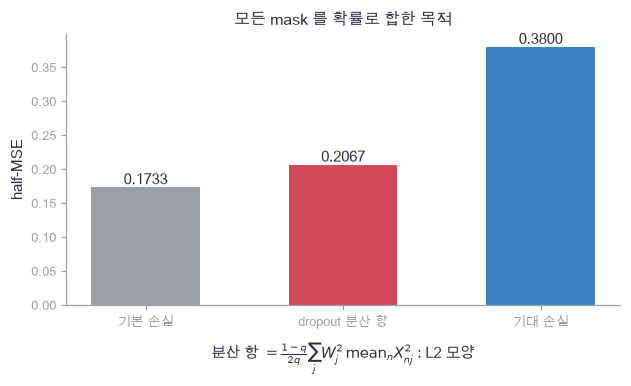

In [37]:
plot_dropout_objective(base_loss, extra_loss, exact_expected_loss)

🔍 **확인** · 네 mask의 확률 가중합이 정확히 "기본 손실 + 분산 항"입니다. 여기서는 관측별 손실의 기대값을 먼저 구해 평균했습니다. 합의 기댓값은 각 기댓값의 합이므로 관측마다 mask를 독립으로 뽑는 경우에도 같은 식이 됩니다.

### ✏️ 연습 5-1 · mask를 고정한 forward와 backward

입력 `H`, 상류 기울기 `G`, 남길 자리가 1인 `mask`, 유지 확률 `q`에서 inverted dropout의 출력 `H_tilde`와 고정 mask의 미분 `dH` 두 줄을 채우세요. mask는 뽑지 않고 인자로 받으므로 손계산이 됩니다.

In [38]:
def exercise_dropout_fixed_mask(H, G, mask, q):
    """연습 5-1: 주어진 mask로 inverted dropout forward와 backward. H, G, mask: 같은 모양, q: 유지 확률 → (H_tilde, dH: 같은 모양)."""
    assert H.shape == G.shape == mask.shape, "H, G, mask는 같은 모양이어야 합니다"
    assert 0 < q <= 1, "유지 확률 q는 0보다 크고 1 이하여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 남긴 자리에 1/q를 곱한 H_tilde = H ⊙ M/q 와, 같은 mask를 그대로 곱한 dH = G ⊙ M/q
    ### 힌트: 5절 dropout_forward의 마지막 줄과 dropout_backward의 한 줄입니다. 여기서는 mask를 뽑지 않고 인자로 받습니다.
    raise NotImplementedError
    return H_tilde, dH

In [39]:
def check_dropout_fixed_mask(candidate):
    """(2, 3) 손계산 하나와 본문 dropout_forward·dropout_backward의 mask로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: dropout_forward, dropout_backward (5절)
    example_H = np.array([[1., -2., .5], [3., .4, -1.]])          # (2, 3)
    example_G = np.array([[1., 1., 1.], [2., 2., 2.]])            # (2, 3): 상류 기울기
    example_mask = np.array([[1., 0., 1.], [0., 1., 1.]])         # (2, 3): 남길 자리 1
    H_tilde, dH = candidate(example_H, example_G, example_mask, .5)
    assert H_tilde.shape == (2, 3), f"출력은 H와 같은 (2, 3)이어야 하는데 {H_tilde.shape}입니다"
    np.testing.assert_allclose(H_tilde, [[2., 0., 1.], [0., .8, -2.]])   # 검산: 남긴 자리는 1/q = 2배, 지운 자리는 0
    np.testing.assert_allclose(dH, [[2., 0., 2.], [0., 4., 4.]])         # 검산: 기울기도 같은 mask로 2배 또는 0
    dropped, multiplier = dropout_forward(example_H, .7, np.random.default_rng(14))   # 본문 함수가 뽑은 mask (배율 1/q 또는 0)
    H_tilde_b, dH_b = candidate(example_H, example_G, (multiplier > 0).astype(float), .7)
    np.testing.assert_allclose(H_tilde_b, dropped)                      # 검산: 같은 mask면 dropout_forward와 같음
    np.testing.assert_allclose(dH_b, dropout_backward(example_G, multiplier))   # 검산: dropout_backward와 같음
    print("고정 mask의 forward·backward: 손계산과 일치합니다.")

run_check(check_dropout_fixed_mask, exercise_dropout_fixed_mask, hint="H_tilde = H * mask / q · dH = G * mask / q")

☐ exercise_dropout_fixed_mask: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: H_tilde = H * mask / q · dH = G * mask / q


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
H_tilde = H * mask / q
dH = G * mask / q
```

</details>

### ✏️ 연습 5-2 · 평균 목적에 더해지는 분산 항

입력 `X` `(N, D)`, 가중치 `w` `(D,)`, 유지 확률 `q`에서 모든 mask의 평균 목적이 원래 손실에 더하는 항 $\frac{1-q}{2q}\sum_jW_j^2\,\mathrm{mean}_nX_{nj}^2$ 한 줄을 채우세요. 검사는 손계산 하나와, 위 셀에서 네 mask의 확률 가중합으로 얻은 정확한 기댓값에서 기본 손실을 뺀 값으로 합니다.

In [40]:
def exercise_dropout_variance_term(X, w, q):
    """연습 5-2: 입력 dropout 선형 모델의 제곱 손실을 mask 평균했을 때 더해지는 분산 항. X: (N, D), w: (D,), q: 유지 확률 → 숫자."""
    assert X.shape[1] == w.shape[0], "X의 열 수 D와 w의 길이 D가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: (1 − q)/(2q) 에 Σ_j w_j² · mean_n X_nj² 를 곱한 extra (숫자 하나)
    ### 힌트: 5절 평균 목적 셀의 extra_loss 한 줄입니다. 관측 축 평균은 axis=0입니다.
    raise NotImplementedError
    return extra

In [41]:
def check_dropout_variance_term(candidate):
    """(2, 2) 손계산 하나와 5절 평균 목적 셀의 값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: X_two, w_two, q_keep, extra_loss, base_loss, exact_expected_loss (5절 평균 목적 셀)
    example_X = np.array([[1., 2.], [-1., 0.]])                 # (2, 2): 열마다 제곱 평균 [1, 2]
    example_w = np.array([1., .5])                              # (2,): 제곱 [1, 0.25]
    extra = candidate(example_X, example_w, .5)
    assert np.ndim(extra) == 0, f"분산 항은 숫자 하나여야 하는데 모양이 {np.shape(extra)}입니다"
    np.testing.assert_allclose(extra, .75)                      # 검산: (1 − 0.5)/(2·0.5) · (1·1 + 0.25·2) = 0.5 · 1.5
    np.testing.assert_allclose(candidate(example_X, example_w, 1.), 0.)   # 검산: q = 1이면 dropout이 없어 분산 항 0
    np.testing.assert_allclose(candidate(X_two, w_two, q_keep), extra_loss)   # 검산: 5절 셀의 분산 항
    np.testing.assert_allclose(candidate(X_two, w_two, q_keep), exact_expected_loss - base_loss, atol=1e-14)   # 검산: 네 mask 기댓값 − 기본 손실
    print("dropout 평균 목적의 분산 항: 손계산과 일치합니다.")

run_check(check_dropout_variance_term, exercise_dropout_variance_term, hint="extra = (1 - q) / (2 * q) * np.sum(w ** 2 * np.mean(X ** 2, axis=0))")

☐ exercise_dropout_variance_term: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: extra = (1 - q) / (2 * q) * np.sum(w ** 2 * np.mean(X ** 2, axis=0))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
extra = (1 - q) / (2 * q) * np.sum(w ** 2 * np.mean(X ** 2, axis=0))
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · Huber 손실과 미분 (1절)

잔차 배열 `r`과 `delta`에서 Huber 손실과 잔차에 대한 미분을 만드는 두 줄을 채우세요.

In [42]:
def exercise_huber(r, delta):
    """연습 A: Huber 손실과 미분. r: 어떤 모양, delta: 양수 → (loss, grad: 같은 모양)."""
    assert delta > 0, "delta는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = |r| ≤ delta 면 r²/2, 아니면 delta(|r| − delta/2); grad = r 을 [−delta, delta] 로 자른 값
    ### 힌트: np.where(np.abs(r) <= delta, ..., ...), np.clip(r, -delta, delta)
    raise NotImplementedError
    return loss, grad

In [43]:
def check_huber(candidate):
    """1절 손계산·그림 곡선과 본문 element_loss로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: shape_r, shape_delta, shape_losses, shape_grads (1절 그림 셀) · element_loss (1절)
    loss_a, grad_a = candidate(np.array([2.]), .5)
    np.testing.assert_allclose(loss_a, .875)                                                           # 검산: 1절 손계산 손실
    np.testing.assert_allclose(grad_a, .5)                                                             # 검산: 1절 손계산 미분
    loss_b, grad_b = candidate(shape_r, shape_delta)
    np.testing.assert_allclose(loss_b, shape_losses["huber"])                                          # 검산: 1절 그림의 곡선
    np.testing.assert_allclose(grad_b, shape_grads["huber"])                                           # 검산: 미분 곡선도 같음
    loss_c, grad_c = candidate(np.array([-0.2, 0.9]), .37)
    ref_c = element_loss(np.array([-0.2, 0.9]), "huber", .37)
    np.testing.assert_allclose(loss_c, ref_c[0])                                                       # 검산: 본문 함수와 같음
    np.testing.assert_allclose(grad_c, ref_c[1])                                                       # 검산: 미분도 같음
    print("Huber: 손계산·그림·element_loss 와 일치합니다.")

run_check(check_huber, exercise_huber, hint="loss = np.where(np.abs(r) <= delta, 0.5 * r ** 2, delta * (np.abs(r) - 0.5 * delta)); grad = np.clip(r, -delta, delta)")

☐ exercise_huber: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = np.where(np.abs(r) <= delta, 0.5 * r ** 2, delta * (np.abs(r) - 0.5 * delta)); grad = np.clip(r, -delta, delta)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = np.where(np.abs(r) <= delta, 0.5 * r ** 2, delta * (np.abs(r) - 0.5 * delta))
grad = np.clip(r, -delta, delta)
```

</details>

### ✏️ 연습 B · 가중 평균의 계수 (2절)

관측 가중치 `weights` $(N,)$와 출력 수 `K`에서 원소별 계수 $a_n/(K\sum_ma_m)$을 $(N,1)$로 만드는 한 줄을 채우세요.

In [44]:
def exercise_normalized_weights(weights, K):
    """연습 B: 가중 평균의 원소별 계수 a_n/(K Σ_m a_m). weights: (N,), K: 출력 수 → (N, 1)."""
    assert weights.ndim == 1, "weights는 (N,) 1차원이어야 합니다"
    assert weights.sum() > 0, "가중치의 합은 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: normalized = weights 를 (N, 1) 로 세워 (가중치 합 × K) 로 나눈 값
    ### 힌트: weights[:, None] / (weights.sum() * K)
    raise NotImplementedError
    return normalized

In [45]:
def check_normalized_weights(candidate):
    """2절의 가중 평균, 모두 1인 경우, 상수배 불변, 본문 regression_loss의 기울기 계수로 검사합니다."""
    # 쓰는 것: wm_weights, wm_values, wm_weighted, wm_pred, wm_target (2절 그림 셀) · regression_loss (2절)
    n_a = candidate(wm_weights, 2)
    assert n_a.shape == (3, 1), f"모양은 (N, 1) = (3, 1)이어야 하는데 {n_a.shape}입니다"
    np.testing.assert_allclose(np.sum(n_a * wm_values), wm_weighted)                                  # 검산: 계수 × 원소 손실의 합 = 2절 가중 평균
    np.testing.assert_allclose(candidate(np.ones(5), 3), np.full((5, 1), 1 / 15))                     # 검산: 모두 1이면 전체 원소 평균 1/(NK)
    np.testing.assert_allclose(candidate(7 * wm_weights, 2), n_a)                                     # 검산: 상수배 불변
    _, grad_ref = regression_loss(wm_pred, wm_target, "mse", weights=wm_weights)
    np.testing.assert_allclose(n_a * (wm_pred - wm_target), grad_ref)                                 # 검산: 계수 × ρ'(r) = 본문의 기울기
    print("가중 평균 계수: 2절·regression_loss 와 일치합니다.")

run_check(check_normalized_weights, exercise_normalized_weights, hint="normalized = weights[:, None] / (weights.sum() * K)")

☐ exercise_normalized_weights: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: normalized = weights[:, None] / (weights.sum() * K)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
normalized = weights[:, None] / (weights.sum() * K)
```

</details>

### ✏️ 연습 C · L2를 붙인 가중치 기울기 (3절)

입력 `X`, 예측의 기울기 `d_prediction`, 가중치 `W`, 계수 `l2`에서 $dW=X^\top d\hat Y+\lambda W$ 한 줄을 채우세요.

In [46]:
def exercise_l2_gradient(X, d_prediction, W, l2):
    """연습 C: L2를 붙인 가중치 기울기 dW = Xᵀ dŶ + λW. X: (N, D), d_prediction: (N, K), W: (D, K) → (D, K)."""
    assert X.shape[0] == d_prediction.shape[0], "관측 수 N이 같아야 합니다"
    assert W.shape == (X.shape[1], d_prediction.shape[1]), "W는 (D, K)여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dW = X 의 전치 @ d_prediction + l2 · W   (평균은 d_prediction 에 이미 들어 있음)
    ### 힌트: 3절 linear_objective 의 dW 한 줄입니다.
    raise NotImplementedError
    return dW

In [47]:
def check_l2_gradient(candidate):
    """본문 linear_objective의 dW와 λW 항의 분리로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: X_check, Y_check, W_check, b_check, weights_check (3절 검산 셀) · regression_loss (2절) · linear_objective (3절)
    _, d_pred_c = regression_loss(X_check @ W_check + b_check, Y_check, weights=weights_check)
    _, dW_ref, _ = linear_objective(X_check, Y_check, W_check, b_check, weights=weights_check, l2=.3)
    np.testing.assert_allclose(candidate(X_check, d_pred_c, W_check, .3), dW_ref)                     # 검산: 본문 함수와 같음
    np.testing.assert_allclose(candidate(X_check, d_pred_c, W_check, 0.) + .3 * W_check, dW_ref)      # 검산: λ = 0 결과에 λW를 더하면 같음
    print("L2 기울기: linear_objective 와 일치합니다.")

run_check(check_l2_gradient, exercise_l2_gradient, hint="dW = X.T @ d_prediction + l2 * W")

☐ exercise_l2_gradient: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW = X.T @ d_prediction + l2 * W


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW = X.T @ d_prediction + l2 * W
```

</details>

### ✏️ 연습 D · AdamW의 갱신식 (4절)

보정된 모멘트 `m_hat`, `v_hat`와 학습률·epsilon·감쇠 계수에서 새 `W`를 만드는 한 줄을 채우세요. 감쇠는 상태 밖에서 곱합니다.

In [48]:
def exercise_adamw_update(W, m_hat, v_hat, lr, eps, weight_decay):
    """연습 D: AdamW 갱신식. W, m_hat, v_hat: 같은 모양 → 새 W."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: updated = (1 − lr·weight_decay)·W − lr·m_hat / (sqrt(v_hat) + eps)
    ### 힌트: 4절 AdamW 식. epsilon 은 제곱근 바깥에 더합니다.
    raise NotImplementedError
    return updated

In [49]:
def check_adamw_update(candidate):
    """4절 첫 스텝 손계산과 본문 adam_step으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: step_W0, step_g, step_lr, step_decay, step_decoupled (4절 그림 셀) · adam_step (4절)
    np.testing.assert_allclose(candidate(step_W0, step_g, step_g ** 2, step_lr, 1e-8, step_decay), step_decoupled)   # 검산: 4절 첫 스텝 (m̂ = g, v̂ = g²)
    rng_c = np.random.default_rng(141)
    W_c, g_c = rng_c.normal(size=3), rng_c.normal(size=3)
    W_ref, state_c = adam_step(W_c, g_c, (np.zeros(3), np.zeros(3), 0), lr=.1, beta1=.5, beta2=.75, eps=.03, weight_decay=.2)
    m_hat_c, v_hat_c = state_c[0] / (1 - .5), state_c[1] / (1 - .75)   # 첫 스텝의 보정 모멘트
    np.testing.assert_allclose(candidate(W_c, m_hat_c, v_hat_c, .1, .03, .2), W_ref)                  # 검산: adam_step 과 같음
    print("AdamW 갱신: 4절 손계산·adam_step 과 일치합니다.")

run_check(check_adamw_update, exercise_adamw_update, hint="updated = (1 - lr * weight_decay) * W - lr * m_hat / (np.sqrt(v_hat) + eps)")

☐ exercise_adamw_update: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: updated = (1 - lr * weight_decay) * W - lr * m_hat / (np.sqrt(v_hat) + eps)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
updated = (1 - lr * weight_decay) * W - lr * m_hat / (np.sqrt(v_hat) + eps)
```

</details>

### 🔍 완성 예제 · 가중 Huber를 실제 학습에 연결하기

아래 검사기는 후보 손실 함수를 세 손실·출력 축·가중치·배치 반복·전체 모델에 넣어 봅니다. 본문의 `regression_loss`로 통과시킨 뒤, `fit_linear`에 연결해 $\delta=.1,.3,1$을 비교합니다.

In [50]:
def check_regression_loss(candidate):
    """손실 함수 후보를 검사: 세 손실·두 출력 폭·가중치 0 포함·배치 반복(관측 두 배)·전체 선형 모델. 통과하면 문자열을 돌려줍니다."""
    # 쓰는 것: regression_loss (2절) · linear_objective (3절)
    local_rng = np.random.default_rng(147)
    for N, K in [(2, 3), (5, 1)]:
        pred, target = local_rng.normal(size=(N, K)), local_rng.normal(size=(N, K))
        weights = np.arange(N, dtype=float)  # 가중치 0인 관측도 포함합니다.
        for kind in ['mse', 'mae', 'huber']:
            value, grad = candidate(pred.copy(), target.copy(), kind, .37, weights.copy())
            assert np.ndim(value) == 0, "손실값은 숫자 하나여야 합니다"
            assert np.shape(grad) == pred.shape, "기울기는 예측과 같은 모양이어야 합니다"
            reference, reference_grad = regression_loss(pred, target, kind, .37, weights)
            np.testing.assert_allclose(value, reference, atol=1e-12)                                  # 검산: 본문 함수의 값
            np.testing.assert_allclose(grad, reference_grad, atol=1e-12)                              # 검산: 본문 함수의 기울기
            twice_value, twice_grad = candidate(np.repeat(pred, 2, axis=0), np.repeat(target, 2, axis=0), kind, .37, np.repeat(weights, 2))
            np.testing.assert_allclose(twice_value, value)                                            # 검산: 관측을 두 배로 해도 평균은 그대로
            np.testing.assert_allclose(twice_grad, np.repeat(grad, 2, axis=0)/2)                      # 검산: 관측별 기울기는 절반
    X, Y = local_rng.normal(size=(6, 2)), local_rng.normal(size=(6, 2))
    W, b = local_rng.normal(size=(2, 2)), local_rng.normal(size=2)
    value, dW, db = linear_objective(X, Y, W, b, l2=.2, loss_fn=candidate)                          # 후보를 전체 모델에 끼움
    reference = linear_objective(X, Y, W, b, l2=.2)
    for actual, expected in zip((value, dW, db), reference):
        np.testing.assert_allclose(actual, expected, atol=1e-11)                                      # 검산: 목적·dW·db가 본문과 같음
    return '통과: 손실·출력 축·가중치·배치 반복·전체 모델'

In [51]:
# 쓰는 것: regression_loss (2절) · fit_linear (3절) · X_train, Y_train, X_clean, Y_clean (3절 완성 예제 셀)
print(check_regression_loss(regression_loss))
delta_results = {}                                          # δ → 깨끗한 함수 RMSE
for delta in [.1, .3, 1.]:
    W, b, _ = fit_linear(X_train, Y_train, 'huber', delta=delta)
    delta_results[delta] = float(np.sqrt(np.mean((X_clean @ W+b-Y_clean)**2)))
print('delta별 깨끗한 함수 RMSE:', delta_results)

통과: 손실·출력 축·가중치·배치 반복·전체 모델
delta별 깨끗한 함수 RMSE: {0.1: 0.010562499617477515, 0.3: 0.057365453459457774, 1.0: 0.21613168053204956}


### ✏️ 준비도 질문 · 다음으로 가기 전, 다섯 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- Huber의 선형 부분에 $-\delta^2/2$가 필요한 이유를 값과 미분으로 설명할 수 있나요? → 1절
- 관측 가중치의 합과 출력 개수가 각각 어느 미분에 들어가는지 쓸 수 있나요? → 2절
- 평균 데이터 손실과 L2의 계수를 정하고 ridge 해와 대조할 수 있나요? → 3절
- Adam + L2와 AdamW의 상태에 들어가는 값이 무엇인지 두 스텝으로 확인할 수 있나요? → 4절
- dropout의 고정 mask 미분·평균 출력·평균 손실을 각각 확인할 수 있나요? → 5절

다음 [15 실험과 평가](15_experiments_evaluation.ipynb)에서 데이터를 나누고 지표·반복 실험으로 이런 선택을 비교합니다.
BatchNorm·LayerNorm과 잔차 블록의 조합은 [확장 경로](../../docs/CURRICULUM.md)의 구조 조합 단원으로 이어집니다.

📎 참고: [AdamW 원논문](https://arxiv.org/abs/1711.05101)의 분리된 가중치 감쇠,
[Dropout 원논문](https://jmlr.org/papers/v15/srivastava14a.html)의 무작위 unit 제거.